# 01 — Exploratory Data Analysis

This notebook explores the satellite image dataset for a **4-class land-type classification** task:
- `cloudy`
- `desert`
- `green_area`
- `water`

Goal: understand class balance, image properties, pixel statistics, and color distributions — all critical inputs for designing a sound ML pipeline.

In [3]:
import os
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import cv2

# Reproducibility
random.seed(42)
np.random.seed(42)

# Paths
DATA_DIR = Path("../data")
CLASSES = ["cloudy", "desert", "green_area", "water"]
CLASS_DIRS = {cls: DATA_DIR / cls for cls in CLASSES}

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("Setup complete. Data dir:", DATA_DIR.resolve())

Setup complete. Data dir: /Users/michelangelonardi/Desktop/Università/Master/Bocconi Master/Year 2/Semester2 UW/AI for Agriculture/Final Project/AI_agri_project_noAI/data


## 1. Dataset Overview

In [4]:
# Collect file paths and metadata
records = []
for cls in CLASSES:
    paths = sorted(CLASS_DIRS[cls].glob("*.jpg"))
    for p in paths:
        records.append({"class": cls, "path": str(p), "filename": p.name})

df = pd.DataFrame(records)

print(f"Total images : {len(df)}")
print(f"Classes: {df['class'].unique().tolist()}")
print()
print(df.groupby("class").size().rename("count").to_frame())

Total images : 5631
Classes: ['cloudy', 'desert', 'green_area', 'water']

            count
class            
cloudy       1500
desert       1131
green_area   1500
water        1500


## 2. Class Distribution

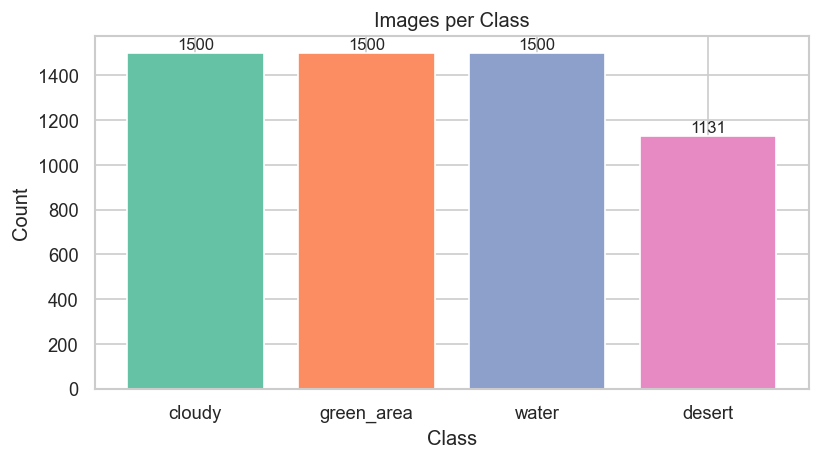

In [5]:
counts = df.groupby("class").size().reset_index(name="count").sort_values("count", ascending=False)
total = counts["count"].sum()
counts["pct"] = (counts["count"] / total * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))

# Bar chart only
palette = sns.color_palette("Set2", len(CLASSES))
bars = ax.bar(counts["class"], counts["count"], color=palette)
ax.set_title("Images per Class")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

for bar, val in zip(bars, counts["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 15, str(val),
            ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## 3. Image Dimensions & Consistency

=== Unique image modes ===
mode
RGB     600
CMYK    200

=== Unique (width × height) combinations ===
 width  height  count
    64      64    400
   256     256    400

=== Stats by class ===
            width                                                height                                               
            count   mean  std    min    25%    50%    75%    max  count   mean  std    min    25%    50%    75%    max
class                                                                                                                 
cloudy      200.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0  200.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0
desert      200.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0  200.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0
green_area  200.0   64.0  0.0   64.0   64.0   64.0   64.0   64.0  200.0   64.0  0.0   64.0   64.0   64.0   64.0   64.0
water       200.0   64.0  0.0   64.0   64.0   64.0   64.0   64.0  200.0   64.0  0.0   64.0   6

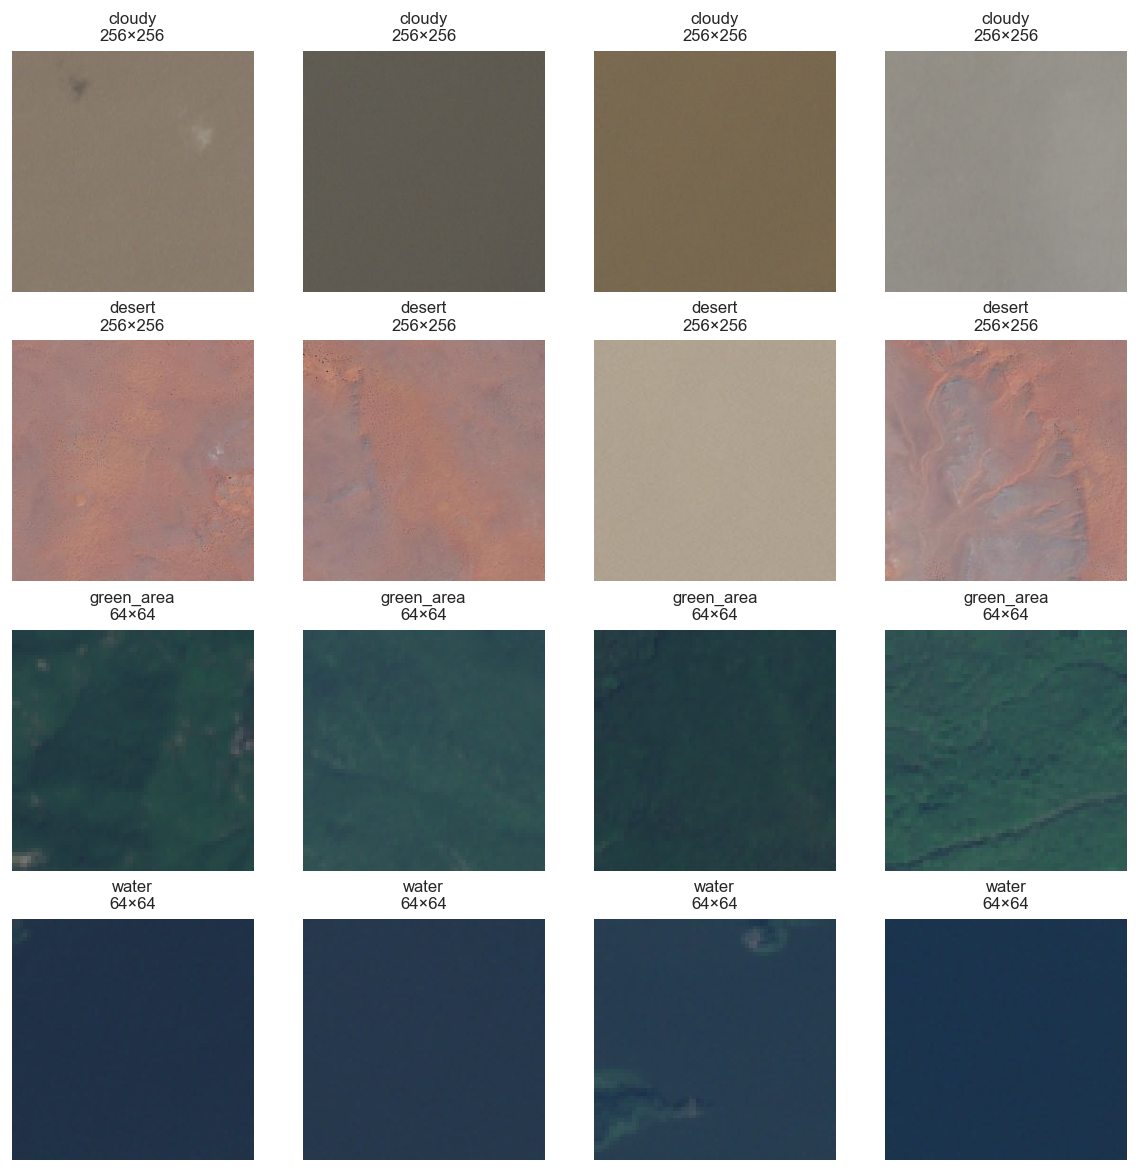

In [6]:
# Sample up to 200 images per class to speed up analysis
SAMPLE_N = 200
shape_records = []

for cls in CLASSES:
    paths = list(CLASS_DIRS[cls].glob("*.jpg")) + list(CLASS_DIRS[cls].glob("*.png"))
    sample = random.sample(paths, min(SAMPLE_N, len(paths)))
    for p in sample:
        with Image.open(p) as img:
            w, h = img.size
            mode = img.mode
        shape_records.append({"class": cls, "width": w, "height": h, "mode": mode,
                               "aspect": round(w / h, 3)})

shape_df = pd.DataFrame(shape_records)

print("=== Unique image modes ===")
print(shape_df["mode"].value_counts().to_string())
print()
print("=== Unique (width × height) combinations ===")
print(shape_df.groupby(["width", "height"]).size().reset_index(name="count").to_string(index=False))
print()
print("=== Stats by class ===")
print(shape_df.groupby("class")[["width", "height"]].describe().round(1).to_string())
# print size of 4 images for each class
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, cls in enumerate(CLASSES):
    paths = list(CLASS_DIRS[cls].glob("*.jpg")) + list(CLASS_DIRS[cls].glob("*.png"))
    sample = random.sample(paths, min(4, len(paths)))
    for j, p in enumerate(sample):
        with Image.open(p) as img:
            w, h = img.size
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{cls}\n{w}×{h}", fontsize=10)
            axes[i, j].axis("off")

## 4. Sample Images per Class

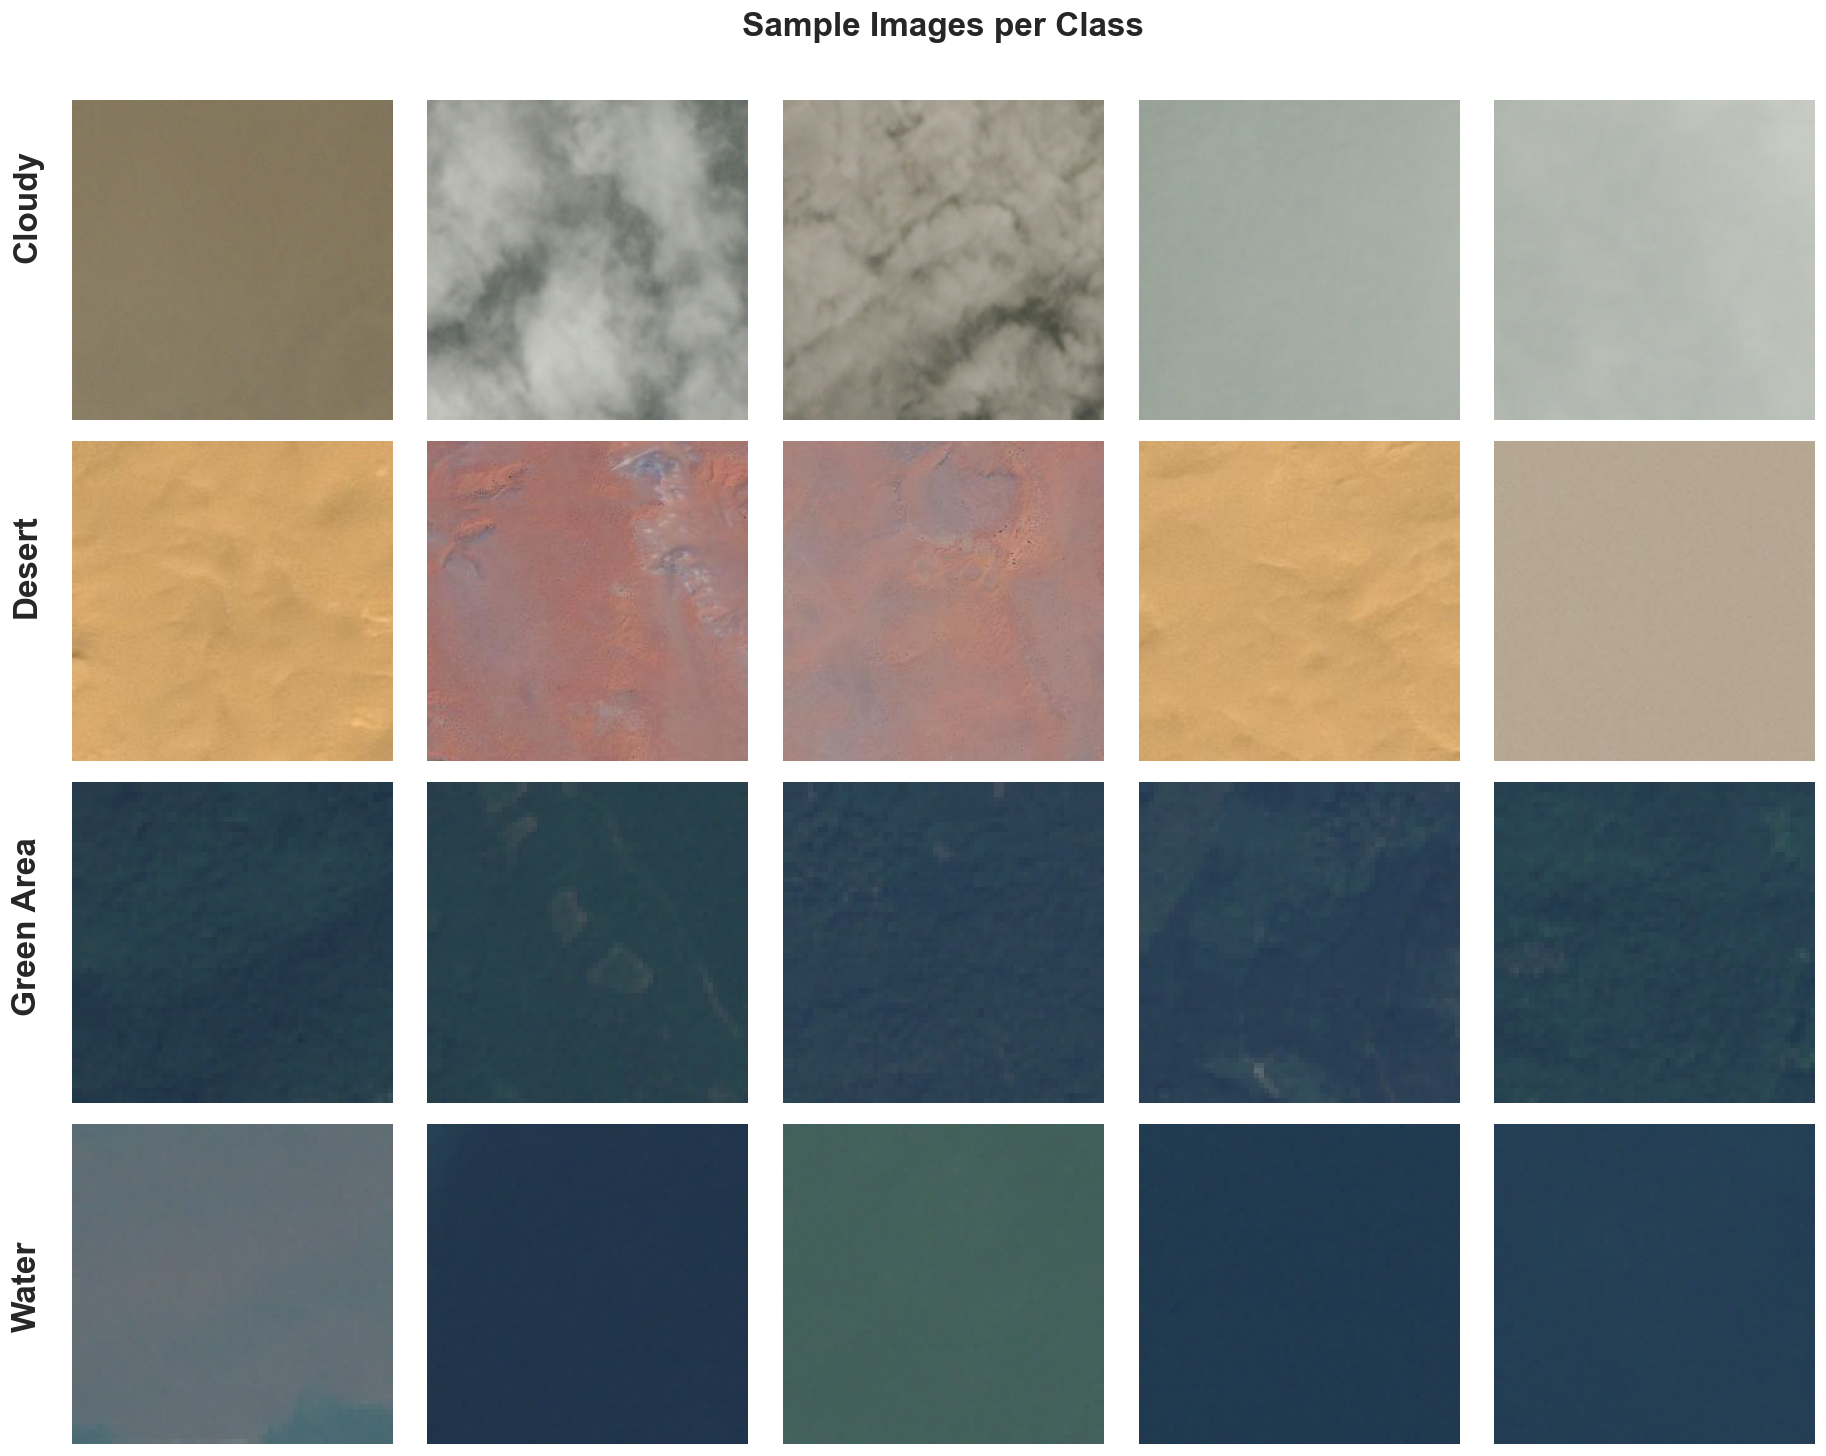

In [7]:
COLS = 5  # samples per class
fig, axes = plt.subplots(len(CLASSES), COLS, figsize=(COLS * 3, len(CLASSES) * 3))

for row_idx, cls in enumerate(CLASSES):
    paths = list(CLASS_DIRS[cls].glob("*.jpg")) + list(CLASS_DIRS[cls].glob("*.png"))
    samples = random.sample(paths, COLS)
    for col_idx, p in enumerate(samples):
        ax = axes[row_idx][col_idx]
        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        ax.axis("off")

# Add vertical class labels on the left side
for row_idx, cls in enumerate(CLASSES):
    # Get the vertical center of the row
    y_pos = (len(CLASSES) - row_idx - 0.5) / len(CLASSES)
    fig.text(-0.00, y_pos, cls.replace("_", " ").title(),
             fontsize=20, fontweight="bold", ha="right", va="center", rotation=90)

plt.suptitle("Sample Images per Class", fontsize=20, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Per-Class Pixel Statistics (Mean & Std)

Per-class pixel mean & std (0-255 scale):
                mean_R      mean_G      mean_B      std_R      std_G  \
cloudy      152.619995  152.869995  143.139999  33.740002  31.510000   
desert      182.039993  154.289993  126.430000  19.740000  21.700001   
green_area   39.310001   64.269997   75.599998   7.900000   8.830000   
water        46.450001   71.959999   88.129997  22.620001  24.350000   

                std_B  
cloudy      33.310001  
desert      20.750000  
green_area   8.550000  
water       15.450000  


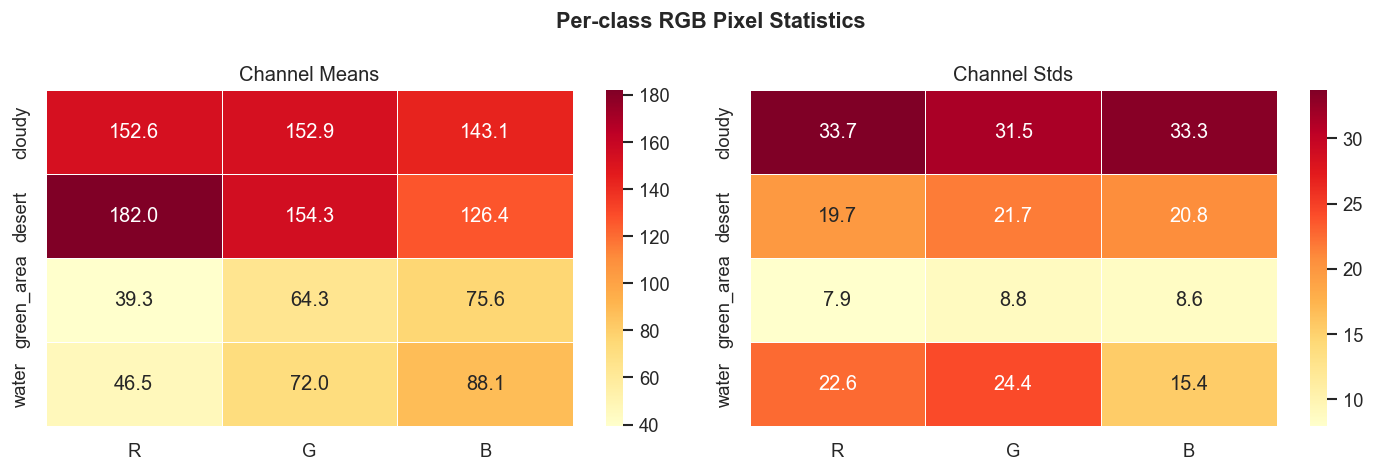

In [8]:
PIXEL_SAMPLE = 100  # images per class for speed
TARGET_SIZE  = (64, 64)  # resize before computing stats

pixel_stats = {}   # cls -> {"mean": [R,G,B], "std": [R,G,B]}
all_pixels   = defaultdict(list)  # cls -> list of flat arrays (for brightness)

for cls in CLASSES:
    paths = list(CLASS_DIRS[cls].glob("*.jpg")) + list(CLASS_DIRS[cls].glob("*.png"))
    sample = random.sample(paths, min(PIXEL_SAMPLE, len(paths)))
    arrays = []
    for p in sample:
        img = np.array(Image.open(p).convert("RGB").resize(TARGET_SIZE), dtype=np.float32)
        arrays.append(img)
        all_pixels[cls].append(img.mean(axis=(0, 1)))   # per-image mean RGB
    stack = np.stack(arrays)   # (N, H, W, 3)
    pixel_stats[cls] = {
        "mean_R": stack[:, :, :, 0].mean(),
        "mean_G": stack[:, :, :, 1].mean(),
        "mean_B": stack[:, :, :, 2].mean(),
        "std_R":  stack[:, :, :, 0].std(),
        "std_G":  stack[:, :, :, 1].std(),
        "std_B":  stack[:, :, :, 2].std(),
    }

stats_df = pd.DataFrame(pixel_stats).T.round(2)
print("Per-class pixel mean & std (0-255 scale):")
print(stats_df)

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cols, title in [
    (axes[0], ["mean_R", "mean_G", "mean_B"], "Channel Means"),
    (axes[1], ["std_R",  "std_G",  "std_B"],  "Channel Stds"),
]:
    sns.heatmap(stats_df[cols].astype(float), annot=True, fmt=".1f",
                cmap="YlOrRd", ax=ax, linewidths=0.5)
    ax.set_title(title)
    ax.set_xticklabels(["R", "G", "B"])
plt.suptitle("Per-class RGB Pixel Statistics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Color Channel Distributions

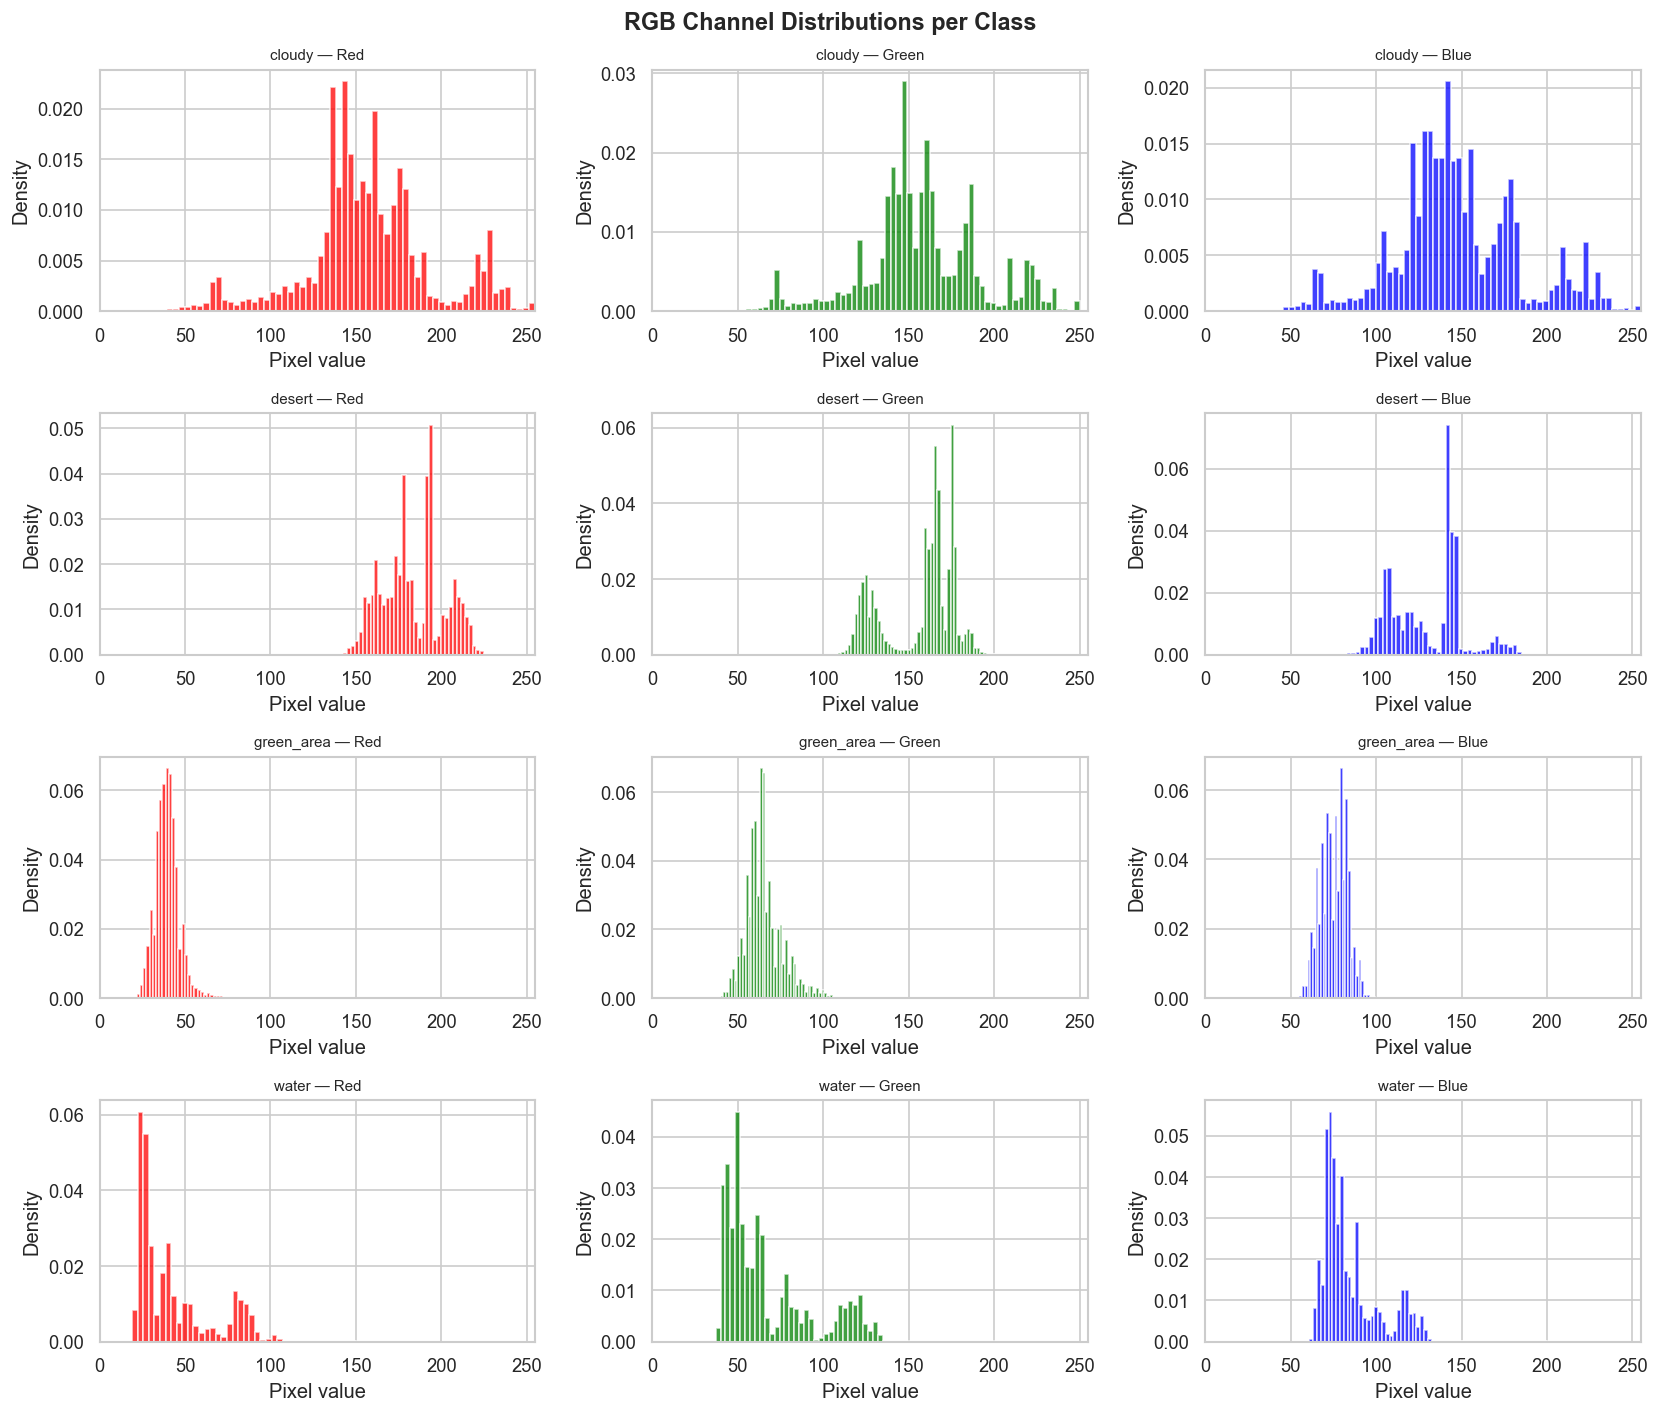

In [9]:
HIST_SAMPLE = 50
channel_names = ["Red", "Green", "Blue"]
channel_colors = ["red", "green", "blue"]

fig, axes = plt.subplots(len(CLASSES), 3, figsize=(14, len(CLASSES) * 3), sharey=False)

for row_idx, cls in enumerate(CLASSES):
    paths = list(CLASS_DIRS[cls].glob("*.jpg")) + list(CLASS_DIRS[cls].glob("*.png"))
    sample = random.sample(paths, min(HIST_SAMPLE, len(paths)))

    # Accumulate per-channel pixel values
    ch_pixels = [[] for _ in range(3)]
    for p in sample:
        arr = np.array(Image.open(p).convert("RGB").resize((64, 64)))
        for c in range(3):
            ch_pixels[c].append(arr[:, :, c].flatten())

    for c in range(3):
        ax = axes[row_idx][c]
        data = np.concatenate(ch_pixels[c])
        ax.hist(data, bins=64, color=channel_colors[c], alpha=0.75, density=True)
        ax.set_xlim(0, 255)
        ax.set_title(f"{cls} — {channel_names[c]}", fontsize=9)
        ax.set_xlabel("Pixel value")
        ax.set_ylabel("Density")

plt.suptitle("RGB Channel Distributions per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Brightness Distribution per Class

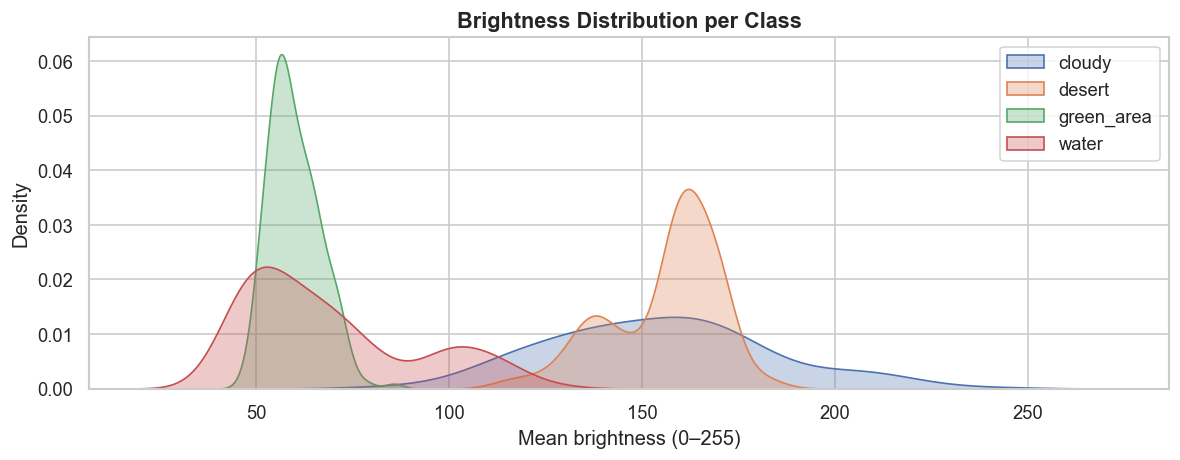

In [10]:
# Brightness = mean pixel value across all channels (perceived luminance proxy)
fig, ax = plt.subplots(figsize=(10, 4))

for cls in CLASSES:
    paths = list(CLASS_DIRS[cls].glob("*.jpg")) + list(CLASS_DIRS[cls].glob("*.png"))
    sample = random.sample(paths, min(200, len(paths)))
    brightness = []
    for p in sample:
        arr = np.array(Image.open(p).convert("RGB").resize((64, 64)), dtype=np.float32)
        brightness.append(arr.mean())
    sns.kdeplot(brightness, label=cls, fill=True, alpha=0.3, ax=ax)

ax.set_xlabel("Mean brightness (0–255)")
ax.set_ylabel("Density")
ax.set_title("Brightness Distribution per Class", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 8. ML Readiness Summary

In [11]:
from collections import Counter

# Re-check actual sizes from shape_df
size_counts = Counter(zip(shape_df["width"], shape_df["height"]))
all_same_size = len(size_counts) == 1
most_common_size = size_counts.most_common(1)[0][0]

class_counts = df.groupby("class").size()
min_cls, max_cls = class_counts.idxmin(), class_counts.idxmax()
imbalance = class_counts.max() / class_counts.min()

print("=" * 55)
print("  ML READINESS CHECKLIST")
print("=" * 55)
print(f"  Total images          : {len(df)}")
print(f"  Number of classes     : {len(CLASSES)}  {CLASSES}")
print(f"  Class imbalance ratio : {imbalance:.2f}x  (max={max_cls}, min={min_cls})")
print(f"  All images same size? : {all_same_size}  (most common: {most_common_size[0]}×{most_common_size[1]})")
print(f"  All RGB?              : {(shape_df['mode'] == 'RGB').all()}")
print()
print("  RECOMMENDATIONS")
print("-" * 55)
if imbalance > 1.3:
    print(f"  ⚠  Class imbalance detected ({imbalance:.2f}x). Consider:")
    print("     - Weighted loss / weighted sampler")
    print("     - Oversampling minority class (e.g., RandomOverSampler)")
    print("     - Augmentation targeted at minority classes")
else:
    print("  ✓  Classes are fairly balanced — no special handling needed.")

if not all_same_size:
    print(f"  ⚠  Mixed image sizes found. Standardise before feeding to a CNN.")
    print(f"     Suggested resize target: {most_common_size[0]}×{most_common_size[1]} or 224×224 (ImageNet standard)")
else:
    print(f"  ✓  All images are {most_common_size[0]}×{most_common_size[1]} — no resize step needed (but consider 224×224 for pretrained models).")

print()
print("  NORMALISATION (for neural nets)")
print("-" * 55)
for cls in CLASSES:
    s = pixel_stats[cls]
    print(f"  {cls:12s}  mean=({s['mean_R']:.1f}, {s['mean_G']:.1f}, {s['mean_B']:.1f})"
          f"  std=({s['std_R']:.1f}, {s['std_G']:.1f}, {s['std_B']:.1f})")

overall_mean = stats_df[["mean_R","mean_G","mean_B"]].mean()
overall_std  = stats_df[["std_R","std_G","std_B"]].mean()
print()
print(f"  Dataset mean (R,G,B) ≈ ({overall_mean['mean_R']:.1f}, {overall_mean['mean_G']:.1f}, {overall_mean['mean_B']:.1f})")
print(f"  Dataset std  (R,G,B) ≈ ({overall_std['std_R']:.1f},  {overall_std['std_G']:.1f},  {overall_std['std_B']:.1f})")
print()
print("  Use these values in transforms.Normalize() or equivalent.")
print("=" * 55)

  ML READINESS CHECKLIST
  Total images          : 5631
  Number of classes     : 4  ['cloudy', 'desert', 'green_area', 'water']
  Class imbalance ratio : 1.33x  (max=cloudy, min=desert)
  All images same size? : False  (most common: 256×256)
  All RGB?              : False

  RECOMMENDATIONS
-------------------------------------------------------
  ⚠  Class imbalance detected (1.33x). Consider:
     - Weighted loss / weighted sampler
     - Oversampling minority class (e.g., RandomOverSampler)
     - Augmentation targeted at minority classes
  ⚠  Mixed image sizes found. Standardise before feeding to a CNN.
     Suggested resize target: 256×256 or 224×224 (ImageNet standard)

  NORMALISATION (for neural nets)
-------------------------------------------------------
  cloudy        mean=(152.6, 152.9, 143.1)  std=(33.7, 31.5, 33.3)
  desert        mean=(182.0, 154.3, 126.4)  std=(19.7, 21.7, 20.8)
  green_area    mean=(39.3, 64.3, 75.6)  std=(7.9, 8.8, 8.6)
  water         mean=(46.5, 7

## 9. Duplicate Detection

METHOD 1: EXACT DUPLICATES (MD5 File Hash)

Total unique file hashes : 5592
Exact duplicate groups   : 39

Exact duplicates found:
  Hash 11e47660... (2 copies):
    - desert(1007) (1).jpg (desert)
    - desert(1007).jpg (desert)
  Hash aa9a5b26... (2 copies):
    - desert(1008) (1).jpg (desert)
    - desert(1008).jpg (desert)
  Hash 78c32394... (2 copies):
    - desert(1009) (1).jpg (desert)
    - desert(1009).jpg (desert)
  Hash f5771de3... (2 copies):
    - desert(101) (1).jpg (desert)
    - desert(101).jpg (desert)
  Hash a8abcfdb... (2 copies):
    - desert(330) (1).jpg (desert)
    - desert(330).jpg (desert)
  Hash 46a8fea4... (2 copies):
    - desert(331) (1).jpg (desert)
    - desert(331).jpg (desert)
  Hash a9a4a590... (2 copies):
    - desert(332) (1).jpg (desert)
    - desert(332).jpg (desert)
  Hash 198719f3... (2 copies):
    - desert(333) (1).jpg (desert)
    - desert(333).jpg (desert)
  Hash 25c55c94... (2 copies):
    - desert(334) (1).jpg (desert)
    - desert(334).jpg

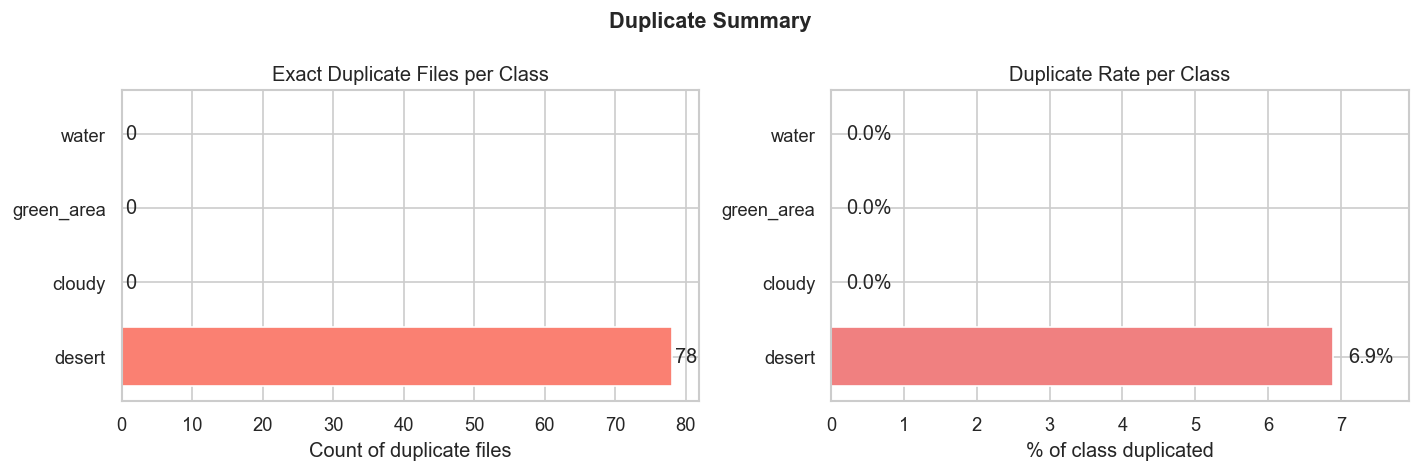

In [12]:
import hashlib
from collections import defaultdict

# ===== METHOD 1: File-level Hash (MD5) =====
# Fast; finds exact byte-for-byte duplicates (same compression/encoding)

print("=" * 60)
print("METHOD 1: EXACT DUPLICATES (MD5 File Hash)")
print("=" * 60)

def compute_md5(filepath, chunk_size=8192):
    """Compute MD5 hash of a file."""
    hash_md5 = hashlib.md5()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

# Hash all files
hashes = defaultdict(list)
for _, row in df.iterrows():
    h = compute_md5(row["path"])
    hashes[h].append(row)

# Find duplicates
exact_dups = {h: files for h, files in hashes.items() if len(files) > 1}

print(f"\nTotal unique file hashes : {len(hashes)}")
print(f"Exact duplicate groups   : {len(exact_dups)}")

if exact_dups:
    print("\nExact duplicates found:")
    for h, files in exact_dups.items():
        print(f"  Hash {h[:8]}... ({len(files)} copies):")
        for f in files:
            print(f"    - {f['filename']} ({f['class']})")
else:
    print("\n✓ No exact byte-for-byte duplicates found.")

print()
# Summarize duplicates per class
print("=" * 60)
print("EXACT DUPLICATE COUNT BY CLASS")
print("=" * 60)

dup_summary = defaultdict(int)
for h, files in exact_dups.items():
    for f in files:
        dup_summary[f["class"]] += 1

# Create summary table
dup_summary_df = pd.DataFrame([
    {"class": cls, "duplicate_files": dup_summary.get(cls, 0), 
     "total_files": len(list(CLASS_DIRS[cls].glob("*.*"))),
     "% duplicated": round(100 * dup_summary.get(cls, 0) / len(list(CLASS_DIRS[cls].glob("*.*"))), 1)}
    for cls in CLASSES
]).sort_values("duplicate_files", ascending=False)

print(dup_summary_df.to_string(index=False))
print()
total_dup_files = dup_summary_df["duplicate_files"].sum()
print(f"Total duplicate files: {total_dup_files} / {len(df)}")
print(f"Unique files if deduplicated: {len(df) - total_dup_files}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(dup_summary_df["class"], dup_summary_df["duplicate_files"], color="salmon")
axes[0].set_xlabel("Count of duplicate files")
axes[0].set_title("Exact Duplicate Files per Class")
for i, (_, row) in enumerate(dup_summary_df.iterrows()):
    axes[0].text(row["duplicate_files"] + 0.5, i, str(int(row["duplicate_files"])), va="center")

axes[1].barh(dup_summary_df["class"], dup_summary_df["% duplicated"], color="lightcoral")
axes[1].set_xlabel("% of class duplicated")
axes[1].set_xlim(0, max(dup_summary_df["% duplicated"]) * 1.15)
axes[1].set_title("Duplicate Rate per Class")
for i, (_, row) in enumerate(dup_summary_df.iterrows()):
    axes[1].text(row["% duplicated"] + 0.2, i, f"{row['% duplicated']:.1f}%", va="center")

plt.suptitle("Duplicate Summary", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Note: File-level vs Pixel-level Comparison

In [13]:
print("""
FILE-LEVEL HASHING vs PIXEL-LEVEL DISTANCES: Do We Need Both?
═══════════════════════════════════════════════════════════════

SHORT ANSWER: **No—we don't need to check pixel-level distances for exact duplicates.**

WHY?
────

• MD5 (file-level hash) checks the **raw bytes** of the file.
  If two .jpg files have identical MD5, their bytes are identical.

• When you load those bytes with PIL/cv2 and decode them, you get the exact same
  pixel arrays. **Decoding is deterministic** — the same input always produces the
  same output.

• Therefore: identical file bytes → identical pixel arrays (always!)

EXCEPTION: If you apply preprocessing during loading (e.g., normalization,
           color space conversion), the decoded pixels might differ slightly due
           to floating-point rounding. But the "raw" pixel values are identical.

CONCLUSION:
───────────
✓ MD5 is sufficient to detect exact duplicates. No need for pixel-level check.
✗ Pixel-level distances are redundant for this use case—they'll always agree
  with MD5 results.

WHEN TO USE EACH:
─────────────────
→ FILE HASHING (MD5):
  • Fast, deterministic, works on compressed files
  • Use to: Detect exact byte-for-byte duplicates
  • Examples: Two files named differently but with identical content
  
→ PIXEL-LEVEL DISTANCES (MSE, cosine distance):
  • Use to: Find near-duplicates after decompression/transformation
  • Example: Comparing image1.jpg (saved with quality=85) vs image1.jpg (quality=95)
    → Same content, different compression → different file hashes
    → But pixel arrays could be visually identical or very similar

→ PERCEPTUAL HASHING (dHash):
  • Best of both worlds: fast (~pixel check time) + robust to compression
  • Use to: Find perceptually similar images (humans would call them duplicates)
  • Example: image.jpg from iPhone vs image.png from Android (same scene)

╚════════════════════════════════════════════════════════════════════════════╝
""")


FILE-LEVEL HASHING vs PIXEL-LEVEL DISTANCES: Do We Need Both?
═══════════════════════════════════════════════════════════════

SHORT ANSWER: **No—we don't need to check pixel-level distances for exact duplicates.**

WHY?
────

• MD5 (file-level hash) checks the **raw bytes** of the file.
  If two .jpg files have identical MD5, their bytes are identical.

• When you load those bytes with PIL/cv2 and decode them, you get the exact same
  pixel arrays. **Decoding is deterministic** — the same input always produces the
  same output.

• Therefore: identical file bytes → identical pixel arrays (always!)

EXCEPTION: If you apply preprocessing during loading (e.g., normalization,
           color space conversion), the decoded pixels might differ slightly due
           to floating-point rounding. But the "raw" pixel values are identical.

CONCLUSION:
───────────
✓ MD5 is sufficient to detect exact duplicates. No need for pixel-level check.
✗ Pixel-level distances are redundant for this use 

In [14]:
# ===== METHOD 2: Perceptual Hash (Difference Hash) =====
# Robust to compression, small edits, rotations; finds visually similar images

print("=" * 60)
print("METHOD 2: NEAR-DUPLICATES (Perceptual Hash - dHash)")
print("=" * 60)

def dhash(img, hash_size=8):
    """
    Compute difference hash of an image.
    Resizes to hash_size+1, computes differences horizontally.
    Fast, robust to compression and small edits.
    """
    # Resize to (hash_size+1) x hash_size grayscale
    img_resized = np.array(img.convert("L").resize((hash_size + 1, hash_size)))
    # Compute row-wise horizontal differences
    diff = img_resized[:, 1:] > img_resized[:, :-1]
    # Pack into integer hash
    h = 0
    for row in diff:
        for bit in row:
            h = (h << 1) | int(bit)
    return h

def hamming_distance(h1, h2):
    """Hamming distance between two integer hashes (# differing bits)."""
    return bin(h1 ^ h2).count("1")

# Compute dHash for all images (sample for speed)
HASH_SAMPLE = 100
dhash_records = []

for cls in CLASSES:
    paths = list(CLASS_DIRS[cls].glob("*.jpg")) + list(CLASS_DIRS[cls].glob("*.png"))
    sample = random.sample(paths, min(HASH_SAMPLE, len(paths)))
    for p in sample:
        try:
            img = Image.open(p)
            h = dhash(img, hash_size=8)
            dhash_records.append({"path": str(p), "filename": p.name, "class": cls, "dhash": h})
        except Exception as e:
            print(f"  Warning: Could not hash {p.name}: {e}")

dhash_df = pd.DataFrame(dhash_records)

# Find near-duplicates with Hamming distance threshold
THRESHOLD = 5  # Allow up to 5 differing bits
near_dups = []

for i, row_i in dhash_df.iterrows():
    for j, row_j in dhash_df.iterrows():
        if i < j:  # Avoid duplicate pairs
            dist = hamming_distance(row_i["dhash"], row_j["dhash"])
            if dist <= THRESHOLD:
                near_dups.append({
                    "file1": row_i["filename"],
                    "file2": row_j["filename"],
                    "class1": row_i["class"],
                    "class2": row_j["class"],
                    "hamming_dist": dist,
                    "similarity": 100 * (1 - dist / 64)  # Max hash size = 64 bits
                })

if near_dups:
    near_dup_df = pd.DataFrame(near_dups).sort_values("hamming_dist")
    print(f"\nNear-duplicates found (Hamming distance ≤ {THRESHOLD}):\n")
    print(near_dup_df[["file1", "file2", "hamming_dist", "similarity"]].to_string(index=False))
else:
    print(f"\n✓ No near-duplicates found (Hamming distance ≤ {THRESHOLD}).")

print(f"\nNote: Sampled {len(dhash_df)} images for this check. Full scan would check all {len(df)} images.")

METHOD 2: NEAR-DUPLICATES (Perceptual Hash - dHash)

Near-duplicates found (Hamming distance ≤ 5):

              file1               file2  hamming_dist  similarity
   SeaLake_1396.jpg    SeaLake_2401.jpg             0    100.0000
    desert(712).jpg    desert(1062).jpg             0    100.0000
    desert(712).jpg     SeaLake_764.jpg             0    100.0000
   SeaLake_2401.jpg    SeaLake_2346.jpg             0    100.0000
    desert(712).jpg     SeaLake_290.jpg             0    100.0000
    desert(712).jpg    SeaLake_1396.jpg             0    100.0000
    desert(712).jpg    SeaLake_2401.jpg             0    100.0000
    desert(712).jpg    SeaLake_2346.jpg             0    100.0000
   desert(1062).jpg    SeaLake_1396.jpg             0    100.0000
   desert(1062).jpg     SeaLake_290.jpg             0    100.0000
    SeaLake_764.jpg     SeaLake_290.jpg             0    100.0000
   desert(1062).jpg     SeaLake_764.jpg             0    100.0000
    SeaLake_764.jpg    SeaLake_1396.jpg   

## 10. Methods for Checking Image Equality

In [15]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    COMPARING IMAGES: METHODS SUMMARY                         ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. FILE-LEVEL HASHING (MD5, SHA256)
   ─────────────────────────────────
   ✓ Fast (hash entire file in O(n) time)
   ✓ Detects exact byte-for-byte duplicates
   ✗ Fails if images are re-compressed or losslessly encoded differently
   ✗ Cannot detect visually similar images
   Use: Remove backup files, detect accidental duplication during data collection
   
   Code:
       import hashlib
       hash_val = hashlib.md5(open(path, "rb").read()).hexdigest()

───────────────────────────────────────────────────────────────────────────────

2. PERCEPTUAL HASHING (Difference Hash - dHash)
   ──────────────────────────────────────────────
   ✓ Robust to compression (JPEG quality loss)
   ✓ Robust to small crops, brightness changes, minor rotations
   ✓ Very fast (8x8 or 16x16 hash)
   ✓ Detects near-duplicates with Hamming distance
   ✗ Less discriminative than pixel-level methods
   Use: Find visually identical or near-identical images; remove duplicates
   
   Code:
       See cell above: dhash() function
       Distance metric: Hamming distance (# differing bits)
       Typical threshold: 0-5 bits (out of 64) = 92%+ similarity

───────────────────────────────────────────────────────────────────────────────

3. STRUCTURAL SIMILARITY INDEX (SSIM)
   ──────────────────────────────────
   ✓ Measures perceived image quality; more aligned with human vision
   ✓ Returns continuous score 0-1 (0 = different, 1 = identical)
   ✗ Slower than perceptual hashing
   Use: Quantifying visual similarity between two specific images
   
   Code:
       from skimage.metrics import structural_similarity as ssim
       score = ssim(img1_array, img2_array, data_range=255, multichannel=True)
       # score > 0.95 = visually identical
       # score > 0.80 = very similar
       # score > 0.50 = similar

───────────────────────────────────────────────────────────────────────────────

4. PIXEL-LEVEL DISTANCES
   ─────────────────────
   ✓ Exact pixel comparison; fully deterministic
   ✗ Slow for large images; sensitive to tiny variations
   Use: Strict equality checks (e.g., unit testing)
   
   Code:
       # Mean Squared Error
       mse = np.mean((img1_array - img2_array) ** 2)
       
       # Only equal if MSE = 0:
       equal = np.allclose(img1_array, img2_array)

───────────────────────────────────────────────────────────────────────────────

5. DEEP LEARNING EMBEDDINGS (Advanced)
   ───────────────────────────────────
   ✓ Captures semantic/high-level image content
   ✓ Robust to geometric transforms, color shifts, crops
   ✗ Requires pre-trained model; computationally expensive
   Use: Finding semantically similar images (even if visually different)
   
   Code:
       from torchvision import models, transforms
       model = models.resnet50(pretrained=True)
       features1 = model(preprocess(img1))  # (1, 2048) embedding
       features2 = model(preprocess(img2))
       
       # Cosine similarity
       similarity = np.dot(features1, features2) / (||features1|| * ||features2||)

───────────────────────────────────────────────────────────────────────────────

RECOMMENDATION FOR THIS DATASET:
  → Use METHOD 2 (dHash) with Hamming threshold 3-5 to find & remove near-duplicates.
  → Run METHOD 1 (MD5) to confirm no exact duplicates exist.
  → For ML training: retain only one image per duplicate group (arbitrary choice).

╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                    COMPARING IMAGES: METHODS SUMMARY                         ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. FILE-LEVEL HASHING (MD5, SHA256)
   ─────────────────────────────────
   ✓ Fast (hash entire file in O(n) time)
   ✓ Detects exact byte-for-byte duplicates
   ✗ Fails if images are re-compressed or losslessly encoded differently
   ✗ Cannot detect visually similar images
   Use: Remove backup files, detect accidental duplication during data collection
   
   Code:
       import hashlib
       hash_val = hashlib.md5(open(path, "rb").read()).hexdigest()

───────────────────────────────────────────────────────────────────────────────

2. PERCEPTUAL HASHING (Difference Hash - dHash)
   ──────────────────────────────────────────────
   ✓ Robust to compression (JPEG quality loss)
   ✓ Robust to small crops, brightness changes, minor rotations
   ✓ 

## 11. Interpreting Pixel Statistics for Model Building

In [16]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║          PIXEL STATISTICS → MODEL BUILDING DECISIONS                         ║
╚══════════════════════════════════════════════════════════════════════════════╝

1️⃣  PER-CLASS PIXEL STATISTICS (Mean & Std)
   ═══════════════════════════════════════
   
   📊 WHAT IT SHOWS:
      • Average brightness & color composition per class
      • Variance (spread) of pixel values within each class
      Example: If green_area mean_G >> mean_R, expect lots of green pixels
   
   🤔 WHAT IT TELLS YOU:
      ✓ Are classes distinguishable by color alone?
      ✓ Do classes have similar lighting conditions?
      ✓ Which color channels carry the most information?
   
   🛠️  HOW TO USE IN MODELS:
   
      a) NORMALIZATION (REQUIRED for all neural networks!)
         ────────────────────────────────────────────────
         Your model expects normalized inputs (mean=0, std=1).
         Use these values in your data pipeline:
         
         import torchvision.transforms as transforms
         
         normalize = transforms.Normalize(
             mean=[mean_R, mean_G, mean_B],  # [values_above]
             std=[std_R, std_G, std_B]       # [values_above]
         )
         
         # Apply during training:
         transform = transforms.Compose([
             transforms.ToTensor(),
             normalize,
         ])
         
         ✓ This centers & scales the input data for better convergence
         ✓ Without this, your model trains 10-100x slower!
      
      b) DETECTING DISTRIBUTION SHIFTS
         ──────────────────────────────
         If one class has wildly different mean/std:
         
         Example:
         • desert:     mean=(180, 160, 140)  ← very bright
         • green_area: mean=(80, 120, 60)    ← darker
         
         → This is GOOD for classification! The model can learn
           brightness as a discriminative feature.
         
         BUT if you have test data from a different camera/time:
         → The mean/std might shift → model might underperform!
         → Add augmentation to handle this: ColorJitter, RandomBrightness
      
      c) INFORMING DATA AUGMENTATION
         ────────────────────────────
         If green_area has low std in Green channel:
         → All images are consistently green
         → Few variations in green tone
         → Add more aggressive color augmentation during training:
         
         transforms.ColorJitter(
             brightness=0.3,
             contrast=0.3,
             saturation=0.3,  # ← Important for this class!
             hue=0.1
         )

─────────────────────────────────────────────────────────────────────────────

2️⃣  COLOR CHANNEL DISTRIBUTIONS
   ═════════════════════════════
   
   📊 WHAT IT SHOWS:
      • Histogram of pixel values for each R, G, B channel per class
      • Whether channels are used equally or dominated by one
      Example: Green_area should peak high on GREEN, low on RED
   
   🤔 WHAT IT TELLS YOU:
      ✓ Which colors are NATURALLY present in each class
      ✓ Do the classes look fundamentally different in color space?
      ✓ Are there outliers (very dark/bright pixels)?
      ✓ Is RGB the right color space, or should we try HSV/Lab?
   
   🛠️  HOW TO USE IN MODELS:
   
      a) COLOR SPACE SELECTION
         ───────────────────────
         If RGB channels are overlapping (similar distributions):
         → RGB might not separate classes well
         → Try converting to HSV (Hue-Saturation-Value):
         
            from PIL import Image
            import colorsys
            
            # Convert to HSV
            def rgb_to_hsv(img):
                return np.array([
                    [colorsys.rgb_to_hsv(*[x/255 for x in pixel])
                     for pixel in row]
                    for row in img.reshape(-1, 3)
                ])
         
         HSV separates COLOR from BRIGHTNESS better!
      
      b) UNDERSTANDING CLASS SEPARABILITY
         ─────────────────────────────────
         Strong separation = high model accuracy likely
         Weak overlap = model might confuse classes
         
         Example interpretation:
         • desert R-histogram: peaks at 180+
         • water  R-histogram: peaks at 100-
         → Easy to separate! Red channel alone is discriminative
         
         • cloudy R-histogram: peaks at 120-150 (same as some water!)
         → Harder! Need the model to learn multi-channel patterns
      
      c) DETECTING PREPROCESSING NEEDS
         ────────────────────────────────
         Bimodal distributions (2 peaks) might mean:
         → Images have very different lighting (early morning vs noon)
         → Need histogram equalization or exposure correction
         → Add augmentation to simulate this variation:
         
         from albumentations import RandomBrightnessContrast
         RandomBrightnessContrast(p=0.5, brightness_limit=0.3, contrast_limit=0.3)
      
      d) FEATURE IMPORTANCE HINTS
         ───────────────────────────
         If GREEN channel has HIGH variance across classes:
         → Green is a discriminative feature
         → Model should learn to weight GREEN channel heavily
         → Consider: does this match domain knowledge? (yes for agricultural)

─────────────────────────────────────────────────────────────────────────────

3️⃣  BRIGHTNESS DISTRIBUTION PER CLASS
   ═════════════════════════════════════
   
   📊 WHAT IT SHOWS:
      • Average luminosity for each class
      • Separates LIGHTING CONDITIONS from content
      Example: desert is bright, cloudy is dim
   
   🤔 WHAT IT TELLS YOU:
      ✓ Is brightness itself a discriminative feature?
      ✓ Are classes collected at different times/conditions?
      ✓ Will the model rely on lighting instead of content?
      ✓ Is the dataset robust to time-of-day variations?
   
   🛠️  HOW TO USE IN MODELS:
   
      a) DETECTING DATA COLLECTION BIAS
         ────────────────────────────────
         Example (hypothetical):
         • desert images: brightness = 180-220 (afternoon sun)
         • water images: brightness = 100-140 (shaded/overcast)
         
         ⚠️  PROBLEM: Model might learn "brightness = class" instead of
             learning actual content! It won't generalize to desert at dawn.
         
         SOLUTION:
            → Add RandomBrightness augmentation (large range):
            
            transforms.ColorJitter(brightness=0.5)  # ±50%
            
            → Ensure test set also has varied brightness
            → Consider histogram equalization preprocessing
      
      b) TIME-OF-DAY ROBUSTNESS
         ───────────────────────
         If brightness distribution is NARROW (std < 20):
         → Limited lighting variation in training data
         → Model won't handle different capture times
         → Augment AGGRESSIVELY with RandomBrightnessContrast
         
         If brightness distribution is WIDE (std > 50):
         → Good! Your model will be robust
         → Can use lighter augmentation
      
      c) HISTOGRAM EQUALIZATION DECISION
         ────────────────────────────────
         Some classes are much brighter than others?
         
         from PIL import ImageOps
         img_equalized = ImageOps.equalize(img)
         
         Pros: Makes texture/content more visible
         Cons: Can look unnatural; might hurt transfer learning
         
         Use only if brightness is clearly hurting classification.

─────────────────────────────────────────────────────────────────────────────

CONCRETE EXAMPLE: How These Analyses Guide Model Design
════════════════════════════════════════════════════════

Hypothetical observations:
├─ desert:     mean=(185, 165, 140),  brightness ≈ 160
├─ green_area: mean=(60, 110, 50),    brightness ≈ 73
├─ water:      mean=(90, 110, 150),   brightness ≈ 110
└─ cloudy:     mean=(110, 125, 140),  brightness ≈ 125

INSIGHTS:
→ Green_area is DARK + GREEN-channel dominant → easily separable
→ Desert is BRIGHT + warm tones → could confuse with cloudy
→ Brightness separates classes → BUT risky for generalization

MODEL PIPELINE:
────────────────
transforms.Compose([
    # 1. Augmentation (to reduce reliance on light)
    transforms.RandomBrightnessContrast(
        brightness_limit=0.4,  ← LARGE because classes differ in brightness
        contrast_limit=0.3,
        p=0.5
    ),
    transforms.ColorJitter(saturation=0.3, hue=0.1),  ← Help generalize color
    
    # 2. Conversion to tensor
    transforms.ToTensor(),
    
    # 3. Normalization (using these exact stats!)
    transforms.Normalize(
        mean=[185/255, 165/255, 140/255],  # ... or use per-class means?
        std=[...],
    ),
])

NOTES:
──────
↪ Use DATASET mean (not per-class) for Normalize() during training
  (You want one normalization, not class-specific)
↪ Per-class means are useful for UNDERSTANDING, not for preprocessing

╚════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║          PIXEL STATISTICS → MODEL BUILDING DECISIONS                         ║
╚══════════════════════════════════════════════════════════════════════════════╝

1️⃣  PER-CLASS PIXEL STATISTICS (Mean & Std)
   ═══════════════════════════════════════
   
   📊 WHAT IT SHOWS:
      • Average brightness & color composition per class
      • Variance (spread) of pixel values within each class
      Example: If green_area mean_G >> mean_R, expect lots of green pixels
   
   🤔 WHAT IT TELLS YOU:
      ✓ Are classes distinguishable by color alone?
      ✓ Do classes have similar lighting conditions?
      ✓ Which color channels carry the most information?
   
   🛠️  HOW TO USE IN MODELS:
   
      a) NORMALIZATION (REQUIRED for all neural networks!)
         ────────────────────────────────────────────────
         Your model expects normalized inputs (mean=0, std=1).
         Use these values in your data pipel